<a href="https://colab.research.google.com/github/jaiganeshnagasubramanian2007-max/main/blob/main/Copy_of_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
  Order_ID  Order_Date            Product     Category  Quantity    Price  \
0  ORD1001  2025-11-24          USB Cable  Accessories       2.0    342.0   
1  ORD1002  2025-10-07         Smartwatch    Wearables       1.0   6582.0   
2  ORD1003  2025-04-30          USB Cable  Accessories       6.0    758.0   
3  ORD1004  2025-08-03  Bluetooth Speaker  Electronics       1.0   3307.0   
4  ORD1005  2025-12-24         Smartphone  Electronics       3.0  21349.0   

   Revenue  
0    684.0  
1   6582.0  
2   4548.0  
3   3307.0  
4  64047.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    205 non-null    object 
 1   Order_Date  205 non-null    object 
 2   Product     202 non-null    object 
 3   Category    205 non-null    object 
 4   Quantity    202 non-null    float64
 5   Price       201 non-nul

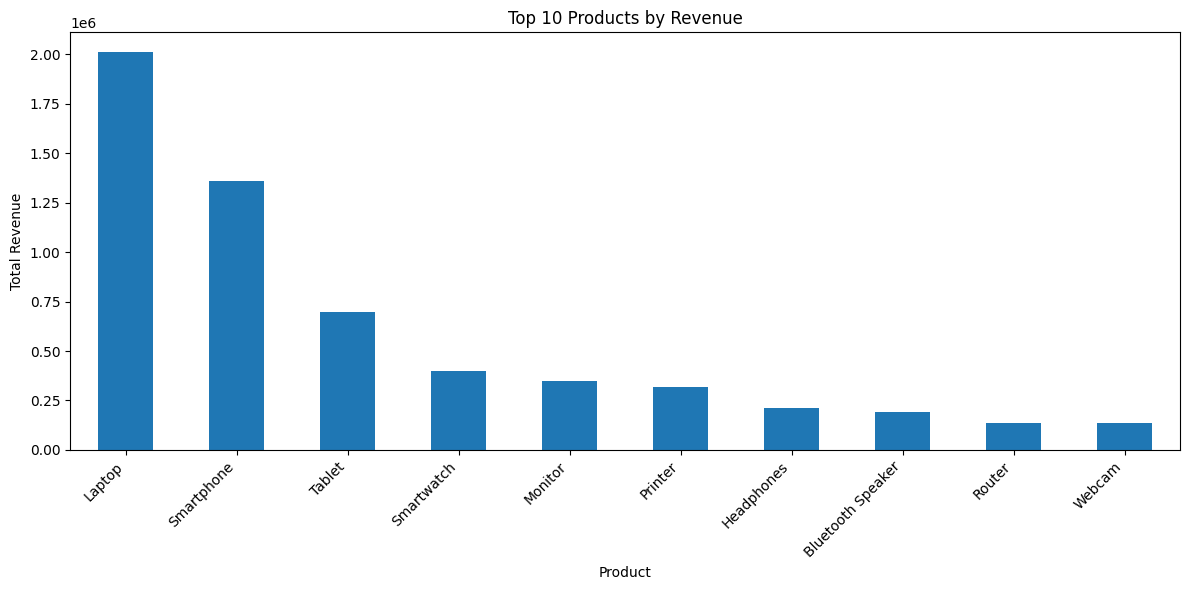

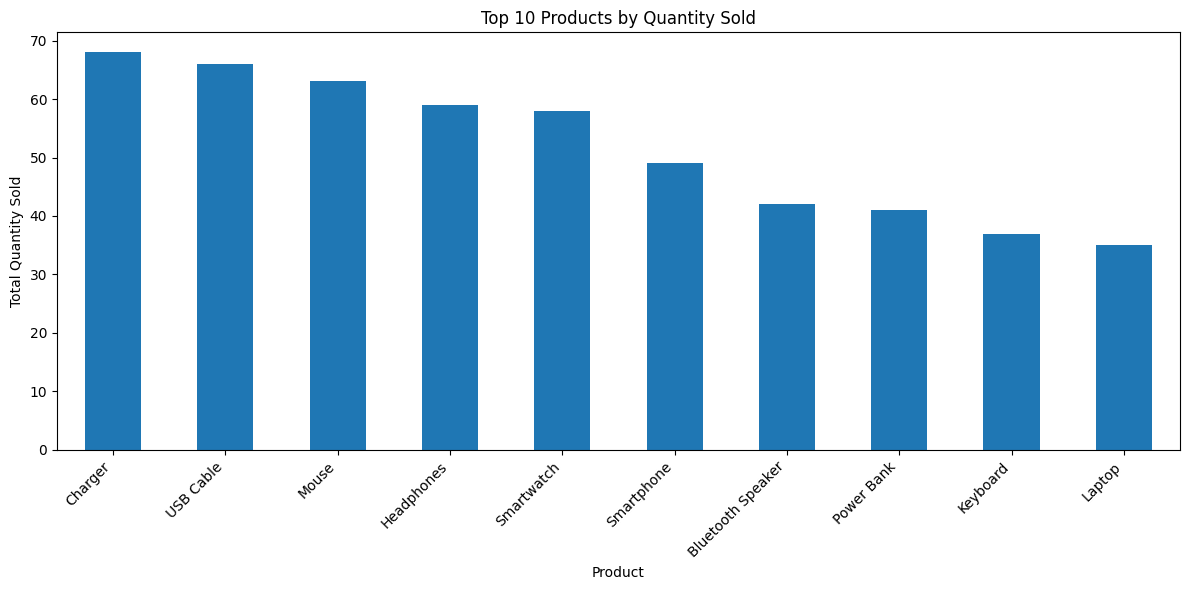

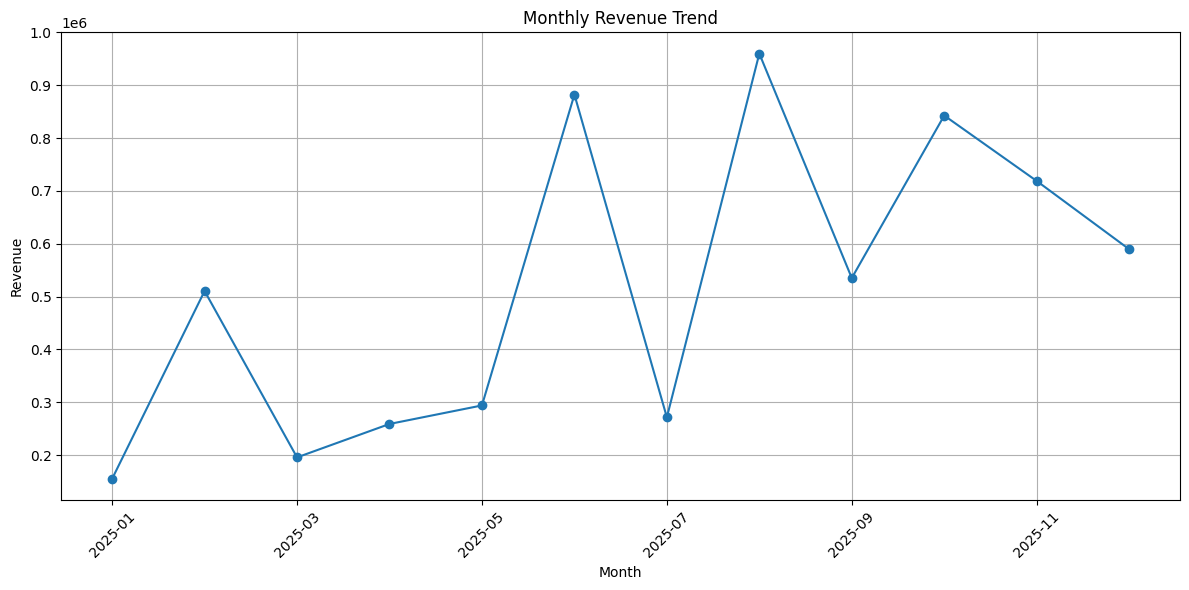


========== KEY INSIGHTS ==========
Highest revenue product: Laptop -> 2009791.00
Top-selling product by quantity: Charger -> 68.0
Best sales month: 2025-08 -> 959942.00
Lowest sales month: 2025-01 -> 154970.00


In [ ]:
# ==========================================
# E-COMMERCE SALES PERFORMANCE ANALYSIS
# ==========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional display settings
pd.set_option('display.max_columns', None)
plt.style.use('default')

# 2. Load Dataset
# Replace with your actual file name if different
df = pd.read_csv('ecommerce_sales_sample.csv')

# 3. Preview Dataset
print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing values before cleaning:")
print(df.isnull().sum())

print("\nNumber of duplicate rows before cleaning:", df.duplicated().sum())

# ==========================================
# 4. DATA CLEANING
# ==========================================

# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values
# Fill missing product names with 'Unknown'
if 'Product' in df.columns:
    df['Product'] = df['Product'].fillna('Unknown')

# Fill missing category if exists
if 'Category' in df.columns:
    df['Category'] = df['Category'].fillna('Unknown')

# Fill missing quantity with median
if 'Quantity' in df.columns:
    df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Fill missing price with median
if 'Price' in df.columns:
    df['Price'] = df['Price'].fillna(df['Price'].median())

# Convert Order_Date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Remove rows where date is invalid
df = df.dropna(subset=['Order_Date'])

# Create Revenue column if not already present
if 'Revenue' not in df.columns:
    df['Revenue'] = df['Quantity'] * df['Price']
else:
    # If revenue exists but has missing values, recalculate/fill
    df['Revenue'] = df['Revenue'].fillna(df['Quantity'] * df['Price'])

# Convert Quantity, Price, Revenue to numeric if needed
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')

# Drop rows with invalid numeric values
df = df.dropna(subset=['Quantity', 'Price', 'Revenue'])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nNumber of duplicate rows after cleaning:", df.duplicated().sum())

print("\nCleaned Dataset Preview:")
print(df.head())

# ==========================================
# 5. TOP-SELLING PRODUCTS ANALYSIS
# ==========================================

# Top products by quantity sold
top_products_qty = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

print("\nTop 10 Products by Quantity Sold:")
print(top_products_qty.head(10))

# Top products by revenue
top_products_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

print("\nTop 10 Products by Revenue:")
print(top_products_revenue.head(10))

# ==========================================
# 6. MONTHLY SALES TREND ANALYSIS
# ==========================================

# Create Month column
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Revenue'].sum().sort_index()

print("\nMonthly Sales Trend:")
print(monthly_sales)

# ==========================================
# 7. VISUALIZATIONS
# ==========================================

# ----- BAR CHART: Top 10 Products by Revenue -----
plt.figure(figsize=(12, 6))
top_products_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ----- BAR CHART: Top 10 Products by Quantity Sold -----
plt.figure(figsize=(12, 6))
top_products_qty.head(10).plot(kind='bar')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ----- LINE CHART: Monthly Sales Trend -----
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================================
# 8. KEY INSIGHTS
# ==========================================

highest_revenue_product = top_products_revenue.idxmax()
highest_revenue_value = top_products_revenue.max()

highest_qty_product = top_products_qty.idxmax()
highest_qty_value = top_products_qty.max()

best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("\n========== KEY INSIGHTS ==========")
print(f"Highest revenue product: {highest_revenue_product} -> {highest_revenue_value:.2f}")
print(f"Top-selling product by quantity: {highest_qty_product} -> {highest_qty_value}")
print(f"Best sales month: {best_month} -> {best_month_sales:.2f}")
print(f"Lowest sales month: {lowest_month} -> {lowest_month_sales:.2f}")

In [ ]:
!pip install numpy matplotlib pandas